# Предсказание привычки курить

In [ ]:

!pip -q install catboost lightgbm xgboost optuna imbalanced-learn cleanlab


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 30.0 MB/s eta 0:00:00


In [ ]:
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from xgboost import XGBClassifier

import optuna
from optuna.samplers import TPESampler
from cleanlab.filter import find_label_issues
from cleanlab.dataset import health_summary

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
N_SPLITS = 5
DATA_DIR = Path("../data")
TARGET = "smoking"
ID_COL = "id"

# Moderate tuning by default. Reduce these values for a quick smoke run.
RUN_OPTUNA = True
N_TRIALS_CAT = 20
N_TRIALS_LGBM = 20
N_TRIALS_XGB = 20

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
np.random.seed(RANDOM_STATE)


## Загрузка данных


In [ ]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print("train:", train.shape)
print("test:", test.shape)

assert TARGET in train.columns
assert ID_COL in train.columns and ID_COL in test.columns

X_raw = train.drop(columns=[TARGET])
y = train[TARGET].astype(int)
X_test_raw = test.copy()

test_ids = X_test_raw[ID_COL].copy()
X = X_raw.drop(columns=[ID_COL])
X_test = X_test_raw.drop(columns=[ID_COL])

print("\nTarget balance:")
print(y.value_counts().rename("count"))
print((y.value_counts(normalize=True).rename("share") * 100).round(2).astype(str) + "%")

print("\nMissing values:")
print("train:", int(train.isna().sum().sum()))
print("test:", int(test.isna().sum().sum()))

train: (15000, 24)
test: (10000, 23)

Target balance:
smoking
0    9491
1    5509
Name: count, dtype: int64
smoking
0    63.27%
1    36.73%
Name: share, dtype: object

Missing values:
train: 0
test: 0


## EDA

Смотрим баланс классов, различие train/test распределений, корреляции с таргетом и распределения наиболее информативных признаков.


In [ ]:
summary = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "train_nunique": X.nunique(),
    "test_nunique": X_test.nunique(),
    "train_missing": X.isna().sum(),
    "test_missing": X_test.isna().sum(),
    "train_mean": X.mean(numeric_only=True),
    "test_mean": X_test.mean(numeric_only=True),
    "train_std": X.std(numeric_only=True),
    "test_std": X_test.std(numeric_only=True),
})

summary["abs_mean_shift_in_train_std"] = (
    (summary["test_mean"] - summary["train_mean"]).abs() / summary["train_std"].replace(0, np.nan)
)

summary.sort_values("abs_mean_shift_in_train_std", ascending=False).head(15)

,dtype,train_nunique,test_nunique,train_missing,test_missing,train_mean,test_mean,train_std,test_std,abs_mean_shift_in_train_std
hearing(right),float64,2,2,0,0,1.005533,1.00750,0.074183,0.086281,0.026511
age,float64,13,14,0,0,42.714667,42.50700,10.494821,10.488134,0.019788
weight(kg),float64,18,17,0,0,64.183333,64.39100,10.900045,11.087669,0.019052
eyesight(left),float64,15,15,0,0,1.034540,1.04011,0.319904,0.300328,0.017411
eyesight(right),float64,14,13,0,0,1.029213,1.03414,0.294338,0.286267,0.016738
height(cm),float64,11,10,0,0,164.643000,164.78100,8.540243,8.574637,0.016159
LDL,float64,141,136,0,0,113.369533,113.09720,20.277830,18.489590,0.013430
hemoglobin,float64,106,104,0,0,14.512480,14.52878,1.392519,1.387176,0.011705
ALT,float64,105,94,0,0,20.819467,20.94260,10.694626,10.474401,0.011514
Urine protein,float64,5,5,0,0,1.017000,1.01530,0.159727,0.149894,0.010643


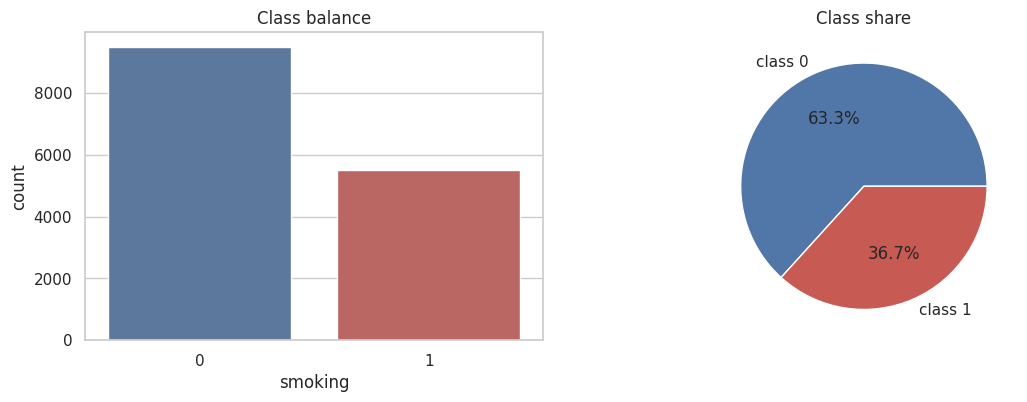

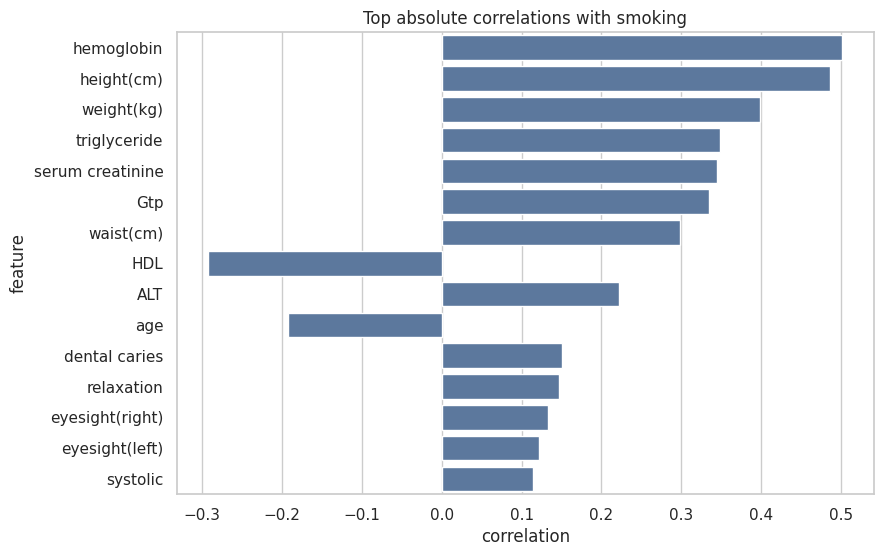

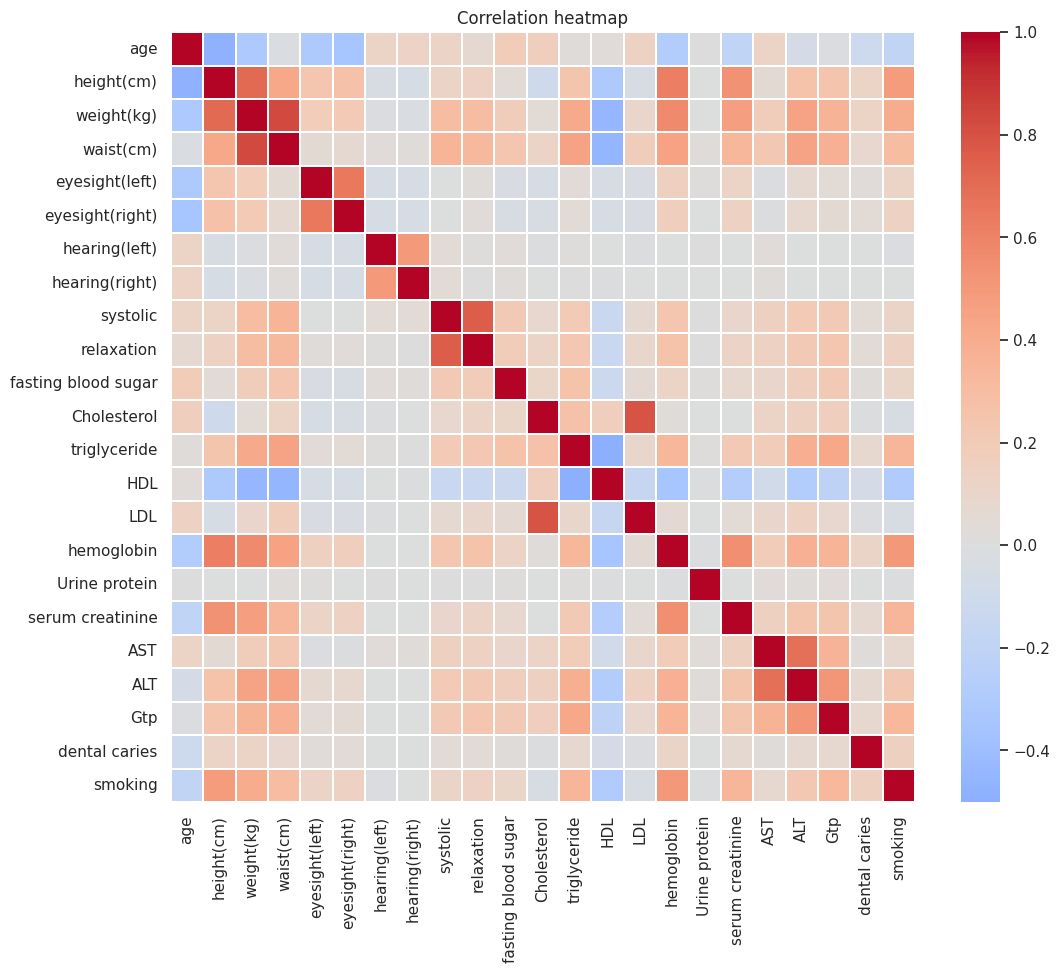

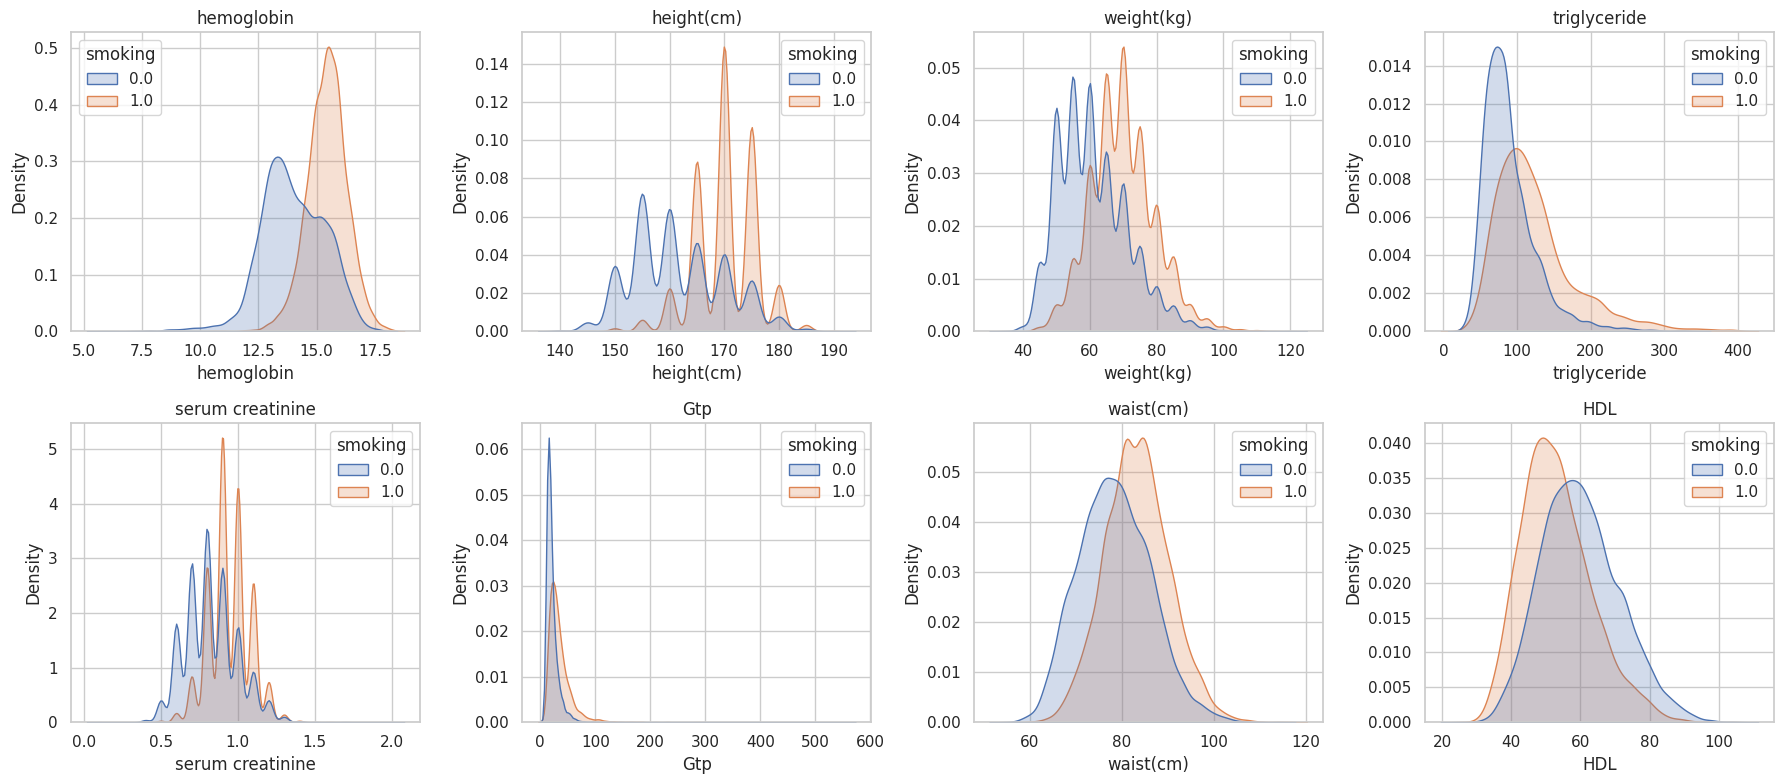

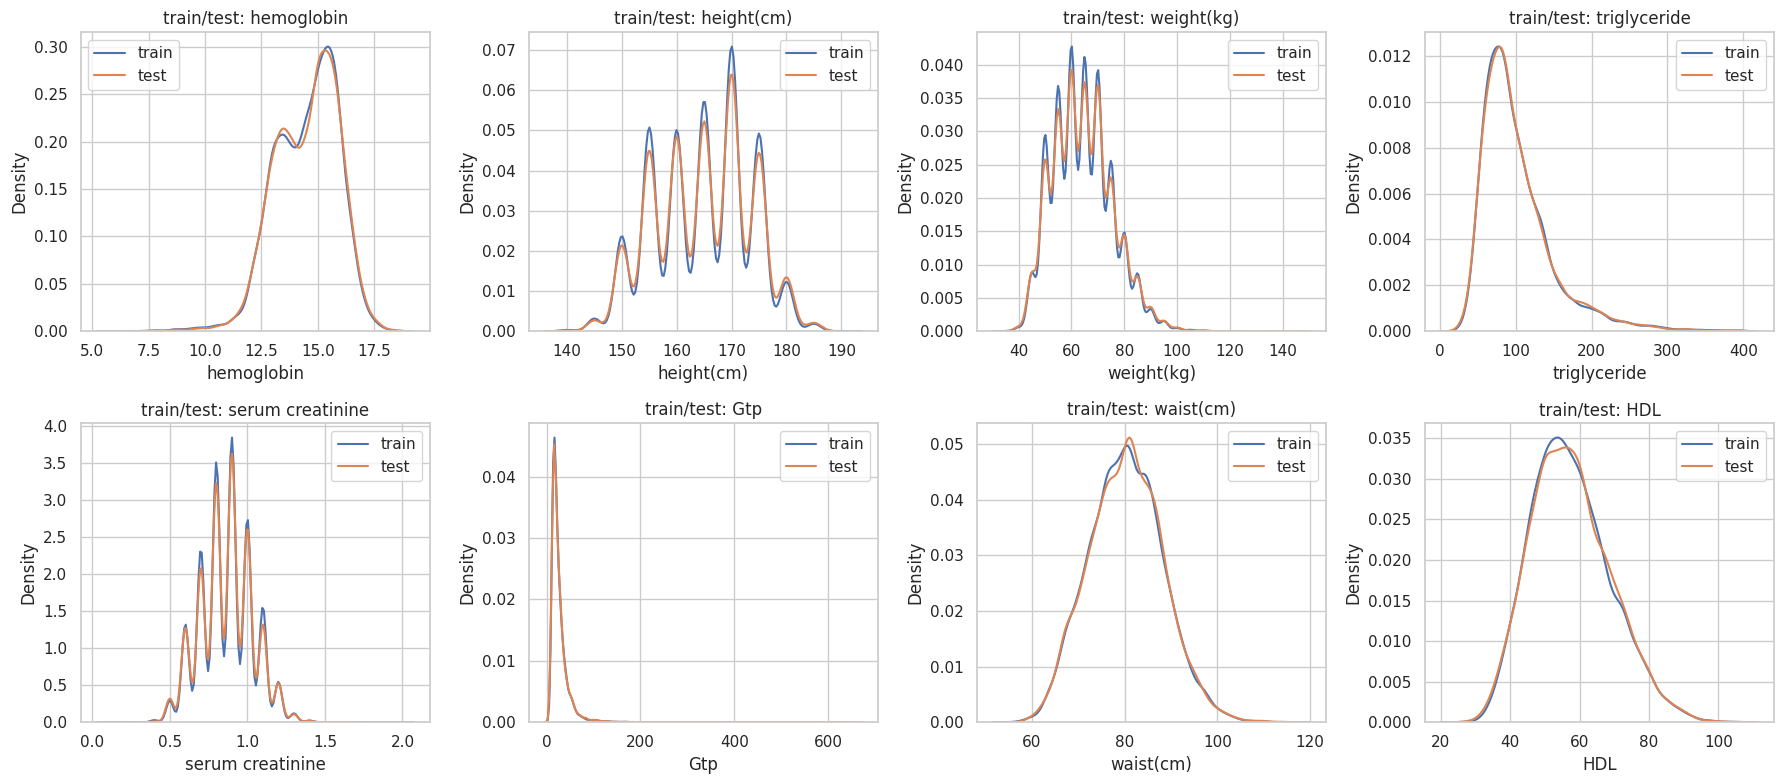

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(x=y, ax=axes[0], palette=["#5177a8", "#c85a54"])
axes[0].set_title("Class balance")
axes[0].set_xlabel("smoking")
axes[0].set_ylabel("count")

balance = y.value_counts(normalize=True).sort_index()
axes[1].pie(balance.values, labels=[f"class {idx}" for idx in balance.index], autopct="%1.1f%%", colors=["#5177a8", "#c85a54"])
axes[1].set_title("Class share")
plt.show()

corr = train.drop(columns=[ID_COL]).corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=corr.head(15).values, y=corr.head(15).index, color="#5177a8")
plt.title("Top absolute correlations with smoking")
plt.xlabel("correlation")
plt.ylabel("feature")
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(train.drop(columns=[ID_COL]).corr(numeric_only=True), cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation heatmap")
plt.show()

key_features = ["hemoglobin", "height(cm)", "weight(kg)", "triglyceride", "serum creatinine", "Gtp", "waist(cm)", "HDL"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), key_features):
    sns.kdeplot(data=train, x=col, hue=TARGET, common_norm=False, fill=True, alpha=0.25, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), key_features):
    sns.kdeplot(X[col], label="train", ax=ax)
    sns.kdeplot(X_test[col], label="test", ax=ax)
    ax.set_title(f"train/test: {col}")
    ax.legend()
plt.tight_layout()
plt.show()


## Feature Engineering

Добавляем компактный набор медицински осмысленных признаков. Для деревьев масштабирование не нужно, а новые отношения и лог-преобразования могут помочь бустингам с разделением классов.

Кратко про новые переменные:

- `BMI` — индекс массы тела, связывает рост и вес.
- `pulse_pressure`, `MAP` — производные признаки давления.
- `cholesterol_ratio`, `ldl_hdl_ratio`, `tg_hdl_ratio`, `ast_alt_ratio` — отношения анализов, которые часто информативнее абсолютных значений.
- `eyesight_diff`, `eyesight_mean`, `hearing_sum` — агрегаты симметричных признаков зрения и слуха.
- `height_hemoglobin`, `creatinine_hemoglobin`, `height_weight_ratio`, `hemoglobin_bmi_ratio`, `creatinine_bmi_ratio`, `height_waist_ratio`, `sex_proxy_score` — proxy/interactions признаки. В данных нет пола, но рост, гемоглобин, креатинин и вес частично кодируют этот фактор, а привычка курить может быть связана с ним.
- `log1p_*` — лог-преобразования скошенных лабораторных признаков, чтобы модели легче работали с выбросами.


In [ ]:

def safe_divide(a, b, eps=1e-6):
    # Безопасное деление: защищает от деления на 0 и бесконечных значений.
    return a / (b.replace(0, np.nan) + eps)


def add_features(df):
    out = df.copy()
    height_m = out["height(cm)"] / 100.0

    # BMI: индекс массы тела. Часто лучше описывает комплекцию, чем рост и вес отдельно.
    out["BMI"] = out["weight(kg)"] / (height_m ** 2 + 1e-6)

    # Производные давления: ширина между верхним и нижним давлением и среднее артериальное давление.
    out["pulse_pressure"] = out["systolic"] - out["relaxation"]
    out["MAP"] = out["relaxation"] + out["pulse_pressure"] / 3.0

    # Отношения липидов и ферментов: помогают деревьям ловить не только уровень анализа,
    # но и баланс между связанными медицинскими показателями.
    out["cholesterol_ratio"] = safe_divide(out["Cholesterol"], out["HDL"])
    out["ldl_hdl_ratio"] = safe_divide(out["LDL"], out["HDL"])
    out["tg_hdl_ratio"] = safe_divide(out["triglyceride"], out["HDL"])
    out["ast_alt_ratio"] = safe_divide(out["AST"], out["ALT"])

    # Агрегаты парных признаков: разница и среднее зрение, суммарный показатель слуха.
    out["eyesight_diff"] = (out["eyesight(left)"] - out["eyesight(right)"]).abs()
    out["eyesight_mean"] = (out["eyesight(left)"] + out["eyesight(right)"]) / 2.0
    out["hearing_sum"] = out["hearing(left)"] + out["hearing(right)"]

    # Proxy/interactions признаки. В датасете нет пола, но рост, гемоглобин, креатинин
    # и вес частично кодируют этот фактор. Эти признаки не являются меткой пола,
    # а лишь дают бустингам дополнительные числовые комбинации.
    out["height_hemoglobin"] = out["height(cm)"] * out["hemoglobin"]
    out["creatinine_hemoglobin"] = out["serum creatinine"] * out["hemoglobin"]
    out["height_weight_ratio"] = safe_divide(out["height(cm)"], out["weight(kg)"])
    out["hemoglobin_bmi_ratio"] = safe_divide(out["hemoglobin"], out["BMI"])
    out["creatinine_bmi_ratio"] = safe_divide(out["serum creatinine"], out["BMI"])
    out["height_waist_ratio"] = safe_divide(out["height(cm)"], out["waist(cm)"])

    # Грубый monotonic proxy score: чем выше рост, гемоглобин, креатинин и вес,
    # тем сильнее сигнал, который модели могут использовать как дополнительную ось разделения.
    out["sex_proxy_score"] = (
        0.45 * out["height(cm)"]
        + 22.0 * out["hemoglobin"]
        + 85.0 * out["serum creatinine"]
        + 0.20 * out["weight(kg)"]
    )

    # log1p уменьшает влияние длинных хвостов и выбросов у скошенных признаков.
    for col in ["triglyceride", "Gtp", "AST", "ALT"]:
        out[f"log1p_{col}"] = np.log1p(out[col].clip(lower=0))

    return out.replace([np.inf, -np.inf], np.nan).fillna(0)


X_fe = add_features(X)
X_test_fe = add_features(X_test)
X_test_fe = X_test_fe[X_fe.columns]

print("Feature count before:", X.shape[1])
print("Feature count after:", X_fe.shape[1])
X_fe.head()


Feature count before: 22
Feature count after: 43


,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,creatinine_hemoglobin,height_weight_ratio,hemoglobin_bmi_ratio,creatinine_bmi_ratio,height_waist_ratio,sex_proxy_score,log1p_triglyceride,log1p_Gtp,log1p_AST,log1p_ALT
0,35.0,170.0,70.0,82.0,1.2,1.2,1.0,1.0,116.0,70.0,...,14.40,2.428571,0.594514,0.041286,2.073171,492.30,4.234107,3.178054,3.091042,3.135494
1,25.0,170.0,65.0,74.0,1.2,1.2,1.0,1.0,110.0,80.0,...,14.22,2.615385,0.702493,0.040015,2.297297,513.60,4.234107,3.555348,2.944439,3.091042
2,45.0,170.0,60.0,81.0,0.9,0.9,1.0,1.0,124.0,77.0,...,12.00,2.833333,0.722500,0.038533,2.098765,486.50,4.919981,3.526361,3.091042,3.178054
3,55.0,165.0,65.0,81.5,0.9,1.0,1.0,1.0,130.0,84.0,...,12.96,2.538461,0.603139,0.037696,2.024540,480.55,4.804021,3.332205,3.044522,3.295837
4,35.0,170.0,60.0,75.6,0.9,0.9,1.0,1.0,110.0,80.0,...,17.00,2.833333,0.818834,0.048167,2.248677,547.50,4.779123,3.526361,3.496508,3.258097


Все сравнения делаем через out-of-fold predictions. Это важно: выбор очистки, веса ансамбля и noisy expert оцениваются на объектах, которые модель не видела при обучении соответствующего fold.


In [ ]:
def positive_class_proba(model, X_part):
    proba = model.predict_proba(X_part)
    if proba.ndim == 1:
        return proba
    return proba[:, 1]


def make_model(model_name, params=None, seed=RANDOM_STATE):
    params = dict(params or {})
    if model_name == "catboost":
        base = dict(
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=seed,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )
        base.update(params)
        return CatBoostClassifier(**base)

    if model_name == "lightgbm":
        base = dict(
            objective="binary",
            metric="auc",
            random_state=seed,
            n_jobs=-1,
            verbosity=-1,
        )
        base.update(params)
        return LGBMClassifier(**base)

    if model_name == "xgboost":
        base = dict(
            objective="binary:logistic",
            eval_metric="auc",
            random_state=seed,
            n_jobs=-1,
            tree_method="hist",
        )
        base.update(params)
        return XGBClassifier(**base)

    raise ValueError(f"Unknown model_name={model_name}")


def fit_model(model, model_name, X_train_part, y_train_part, X_val_part=None, y_val_part=None):
    if X_val_part is None or y_val_part is None:
        model.fit(X_train_part, y_train_part)
        return model

    try:
        if model_name == "catboost":
            model.fit(X_train_part, y_train_part, eval_set=(X_val_part, y_val_part), use_best_model=True, verbose=False)
            return model
        if model_name == "lightgbm":
            model.fit(
                X_train_part,
                y_train_part,
                eval_set=[(X_val_part, y_val_part)],
                eval_metric="auc",
                callbacks=[lgb.early_stopping(100, verbose=False)],
            )
            return model
        if model_name == "xgboost":
            model.fit(X_train_part, y_train_part, eval_set=[(X_val_part, y_val_part)], verbose=False)
            return model
    except TypeError:
        pass

    model.fit(X_train_part, y_train_part)
    return model


def make_pipeline_if_needed(model_name, params, use_smote, seed):
    model = make_model(model_name, params=params, seed=seed)
    if not use_smote:
        return model
    return ImbPipeline([
        ("smote", SMOTE(random_state=seed, k_neighbors=5)),
        ("model", model),
    ])


def make_oof_predictions(model_name, params, X_data, y_data, cv_splitter, use_smote=False, train_mask=None, min_subset_size=500):
    y_array = np.asarray(y_data)
    oof = np.zeros(len(X_data), dtype=float)
    fold_scores = []

    if train_mask is not None:
        train_mask = np.asarray(train_mask, dtype=bool)
        assert len(train_mask) == len(X_data)

    for fold, (train_idx, val_idx) in enumerate(cv_splitter.split(X_data, y_data), start=1):
        selected_train_idx = train_idx
        if train_mask is not None:
            candidate_idx = train_idx[train_mask[train_idx]]
            enough_rows = len(candidate_idx) >= min_subset_size
            enough_classes = len(np.unique(y_array[candidate_idx])) == 2 if len(candidate_idx) else False
            if enough_rows and enough_classes:
                selected_train_idx = candidate_idx

        X_train_part = X_data.iloc[selected_train_idx]
        y_train_part = y_data.iloc[selected_train_idx]
        X_val_part = X_data.iloc[val_idx]
        y_val_part = y_data.iloc[val_idx]

        model = make_pipeline_if_needed(model_name, params, use_smote=use_smote, seed=RANDOM_STATE + fold)
        if use_smote:
            model.fit(X_train_part, y_train_part)
        else:
            model = fit_model(model, model_name, X_train_part, y_train_part, X_val_part, y_val_part)

        val_pred = positive_class_proba(model, X_val_part)
        oof[val_idx] = val_pred
        fold_auc = roc_auc_score(y_val_part, val_pred)
        fold_scores.append(fold_auc)
        print(f"{model_name} | fold {fold}: ROC-AUC={fold_auc:.5f} | train_rows={len(selected_train_idx)} | smote={use_smote}")

        del model
        gc.collect()

    return oof, np.array(fold_scores)


def summarize_oof(name, y_true, pred):
    auc = roc_auc_score(y_true, pred)
    hard_pred = (pred >= 0.5).astype(int)
    return {
        "name": name,
        "roc_auc": auc,
        "accuracy@0.5": accuracy_score(y_true, hard_pred),
        "f1@0.5": f1_score(y_true, hard_pred),
    }


def fit_full_and_predict(model_name, params, X_train_data, y_train_data, X_test_data, use_smote=False):
    model = make_pipeline_if_needed(model_name, params, use_smote=use_smote, seed=RANDOM_STATE)
    model.fit(X_train_data, y_train_data)
    pred = positive_class_proba(model, X_test_data)
    return model, pred

## Baseline

Сначала сравниваем разумные стартовые настройки CatBoost, LightGBM и XGBoost. Это даст основу для Optuna и Cleanlab.


In [ ]:
baseline_params = {
    "catboost": {
        "iterations": 900,
        "learning_rate": 0.035,
        "depth": 6,
        "l2_leaf_reg": 6.0,
        "auto_class_weights": "SqrtBalanced",
    },
    "lightgbm": {
        "n_estimators": 1200,
        "learning_rate": 0.03,
        "num_leaves": 48,
        "max_depth": -1,
        "min_child_samples": 35,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.2,
        "reg_lambda": 3.0,
        "scale_pos_weight": (y.eq(0).sum() / y.eq(1).sum()),
    },
    "xgboost": {
        "n_estimators": 1000,
        "learning_rate": 0.03,
        "max_depth": 5,
        "min_child_weight": 5,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.1,
        "reg_lambda": 4.0,
        "scale_pos_weight": (y.eq(0).sum() / y.eq(1).sum()),
    },
}

baseline_oof = {}
baseline_rows = []

for model_name, params in baseline_params.items():
    print("\n" + "=" * 80)
    print(f"Baseline: {model_name}")
    pred, scores = make_oof_predictions(model_name, params, X_fe, y, cv)
    baseline_oof[model_name] = pred
    row = summarize_oof(f"baseline_{model_name}", y, pred)
    row["fold_mean"] = scores.mean()
    row["fold_std"] = scores.std()
    baseline_rows.append(row)

baseline_report = pd.DataFrame(baseline_rows).sort_values("roc_auc", ascending=False)
baseline_report


Baseline: catboost
catboost | fold 1: ROC-AUC=0.89078 | train_rows=12000 | smote=False
catboost | fold 2: ROC-AUC=0.89930 | train_rows=12000 | smote=False
catboost | fold 3: ROC-AUC=0.88650 | train_rows=12000 | smote=False
catboost | fold 4: ROC-AUC=0.87563 | train_rows=12000 | smote=False
catboost | fold 5: ROC-AUC=0.88397 | train_rows=12000 | smote=False

Baseline: lightgbm
lightgbm | fold 1: ROC-AUC=0.88988 | train_rows=12000 | smote=False
lightgbm | fold 2: ROC-AUC=0.89663 | train_rows=12000 | smote=False
lightgbm | fold 3: ROC-AUC=0.88305 | train_rows=12000 | smote=False
lightgbm | fold 4: ROC-AUC=0.87460 | train_rows=12000 | smote=False
lightgbm | fold 5: ROC-AUC=0.88248 | train_rows=12000 | smote=False

Baseline: xgboost
xgboost | fold 1: ROC-AUC=0.88674 | train_rows=12000 | smote=False
xgboost | fold 2: ROC-AUC=0.89680 | train_rows=12000 | smote=False
xgboost | fold 3: ROC-AUC=0.88200 | train_rows=12000 | smote=False
xgboost | fold 4: ROC-AUC=0.87190 | train_rows=12000 | smote

,name,roc_auc,accuracy@0.5,f1@0.5,fold_mean,fold_std
0,baseline_catboost,0.886761,0.796067,0.751119,0.887237,0.007798
1,baseline_lightgbm,0.884819,0.793333,0.756136,0.885326,0.007443
2,baseline_xgboost,0.884652,0.797400,0.756002,0.884705,0.008047


## Optuna Tuning

Подбирём параметры по 5-fold ROC-AUC.


In [ ]:
def suggest_catboost_params(trial):
    return {
        "iterations": trial.suggest_int("iterations", 700, 1800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.0, 5.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
        "border_count": trial.suggest_int("border_count", 64, 254),
        "auto_class_weights": trial.suggest_categorical("auto_class_weights", [None, "Balanced", "SqrtBalanced"]),
    }


def suggest_lightgbm_params(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 700, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 24, 128),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 100),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 8.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 15.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 2.2),
    }


def suggest_xgboost_params(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 700, 1800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 12.0),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 8.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 15.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 2.2),
    }


suggesters = {
    "catboost": suggest_catboost_params,
    "lightgbm": suggest_lightgbm_params,
    "xgboost": suggest_xgboost_params,
}

trial_counts = {
    "catboost": N_TRIALS_CAT,
    "lightgbm": N_TRIALS_LGBM,
    "xgboost": N_TRIALS_XGB,
}

studies = {}
best_params = {}


def tune_model(model_name):
    def objective(trial):
        params = suggesters[model_name](trial)
        _, scores = make_oof_predictions(model_name, params, X_fe, y, cv)
        return float(scores.mean())

    study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=trial_counts[model_name], show_progress_bar=True)
    return study


if RUN_OPTUNA:
    for model_name in ["catboost", "lightgbm", "xgboost"]:
        print("\n" + "#" * 80)
        print(f"Optuna tuning: {model_name}")
        studies[model_name] = tune_model(model_name)
        best_params[model_name] = studies[model_name].best_params
        print("Best ROC-AUC:", studies[model_name].best_value)
        print("Best params:", best_params[model_name])
else:
    print("RUN_OPTUNA=False: using baseline params as best params.")
    best_params = baseline_params.copy()

[I 2026-06-02 18:46:01,156] A new study created in memory with name: no-name-987adc87-f574-4e2b-a3d5-fc09f697c667



################################################################################
Optuna tuning: catboost


  0%|          | 0/20 [00:00<?, ?it/s]

catboost | fold 1: ROC-AUC=0.88912 | train_rows=12000 | smote=False
catboost | fold 2: ROC-AUC=0.89781 | train_rows=12000 | smote=False
catboost | fold 3: ROC-AUC=0.88477 | train_rows=12000 | smote=False
catboost | fold 4: ROC-AUC=0.87379 | train_rows=12000 | smote=False
catboost | fold 5: ROC-AUC=0.88357 | train_rows=12000 | smote=False
[I 2026-06-02 18:46:57,346] Trial 0 finished with value: 0.8858111419537744 and parameters: {'iterations': 1112, 'learning_rate': 0.07220721098226064, 'depth': 7, 'l2_leaf_reg': 6.009974718380312, 'random_strength': 0.7800932022121826, 'bagging_temperature': 0.7799726016810132, 'border_count': 75, 'auto_class_weights': None}. Best is trial 0 with value: 0.8858111419537744.
catboost | fold 1: ROC-AUC=0.88673 | train_rows=12000 | smote=False
catboost | fold 2: ROC-AUC=0.89711 | train_rows=12000 | smote=False
catboost | fold 3: ROC-AUC=0.88490 | train_rows=12000 | smote=False
catboost | fold 4: ROC-AUC=0.87248 | train_rows=12000 | smote=False
catboost | f

[I 2026-06-02 19:07:38,437] A new study created in memory with name: no-name-2c6197d6-8988-488a-8fbe-dc041bece091


...

lightgbm | fold 1: ROC-AUC=0.88920 | train_rows=12000 | smote=False
lightgbm | fold 2: ROC-AUC=0.89556 | train_rows=12000 | smote=False
lightgbm | fold 3: ROC-AUC=0.88384 | train_rows=12000 | smote=False
lightgbm | fold 4: ROC-AUC=0.87291 | train_rows=12000 | smote=False
lightgbm | fold 5: ROC-AUC=0.88313 | train_rows=12000 | smote=False
[I 2026-06-02 19:07:43,732] Trial 0 finished with value: 0.8849301546091718 and parameters: {'n_estimators': 1187, 'learning_rate': 0.07220721098226064, 'num_leaves': 100, 'max_depth': 7, 'min_child_samples': 28, 'subsample': 0.7045980821176709, 'colsample_bytree': 0.6703292642588699, 'reg_alpha': 2.403053509891533, 'reg_lambda': 0.3238255756528786, 'scale_pos_weight': 1.8496870933552547}. Best is trial 0 with value: 0.8849301546091718.
lightgbm | fold 1: ROC-AUC=0.89073 | train_rows=12000 | smote=False
lightgbm | fold 2: ROC-AUC=0.89706 | train_rows=12000 | smote=False
lightgbm | fold 3: ROC-AUC=0.88219 | train_rows=12000 | smote=False
lightgbm | fold

[I 2026-06-02 19:11:14,690] A new study created in memory with name: no-name-97c5e604-01a4-4e32-bf8b-0dda058bb423


lightgbm | fold 5: ROC-AUC=0.88601 | train_rows=12000 | smote=False
[I 2026-06-02 19:11:14,685] Trial 19 finished with value: 0.88631362333903 and parameters: {'n_estimators': 1349, 'learning_rate': 0.03676952907049367, 'num_leaves': 39, 'max_depth': 4, 'min_child_samples': 80, 'subsample': 0.8721192158739297, 'colsample_bytree': 0.8649419026791835, 'reg_alpha': 0.01552426400958542, 'reg_lambda': 0.007359377896455649, 'scale_pos_weight': 2.042823269036562}. Best is trial 14 with value: 0.8866458459827182.
Best ROC-AUC: 0.8866458459827182
Best params: {'n_estimators': 1380, 'learning_rate': 0.021531971966442735, 'num_leaves': 120, 'max_depth': 4, 'min_child_samples': 64, 'subsample': 0.7642318901400605, 'colsample_bytree': 0.8004332060348538, 'reg_alpha': 0.606798031139906, 'reg_lambda': 0.00847870377539742, 'scale_pos_weight': 1.977508154416172}

################################################################################
Optuna tuning: xgboost


  0%|          | 0/20 [00:00<?, ?it/s]

xgboost | fold 1: ROC-AUC=0.87799 | train_rows=12000 | smote=False
xgboost | fold 2: ROC-AUC=0.89084 | train_rows=12000 | smote=False
xgboost | fold 3: ROC-AUC=0.87590 | train_rows=12000 | smote=False
xgboost | fold 4: ROC-AUC=0.86386 | train_rows=12000 | smote=False
xgboost | fold 5: ROC-AUC=0.87658 | train_rows=12000 | smote=False
[I 2026-06-02 19:11:47,073] Trial 0 finished with value: 0.8770373091389745 and parameters: {'n_estimators': 1112, 'learning_rate': 0.07220721098226064, 'max_depth': 7, 'min_child_weight': 7.585243326167403, 'subsample': 0.7046065241548528, 'colsample_bytree': 0.7045980821176709, 'gamma': 0.2904180608409973, 'reg_alpha': 2.403053509891533, 'reg_lambda': 0.3238255756528786, 'scale_pos_weight': 1.8496870933552547}. Best is trial 0 with value: 0.8770373091389745.
xgboost | fold 1: ROC-AUC=0.88355 | train_rows=12000 | smote=False
xgboost | fold 2: ROC-AUC=0.89118 | train_rows=12000 | smote=False
xgboost | fold 3: ROC-AUC=0.87826 | train_rows=12000 | smote=False

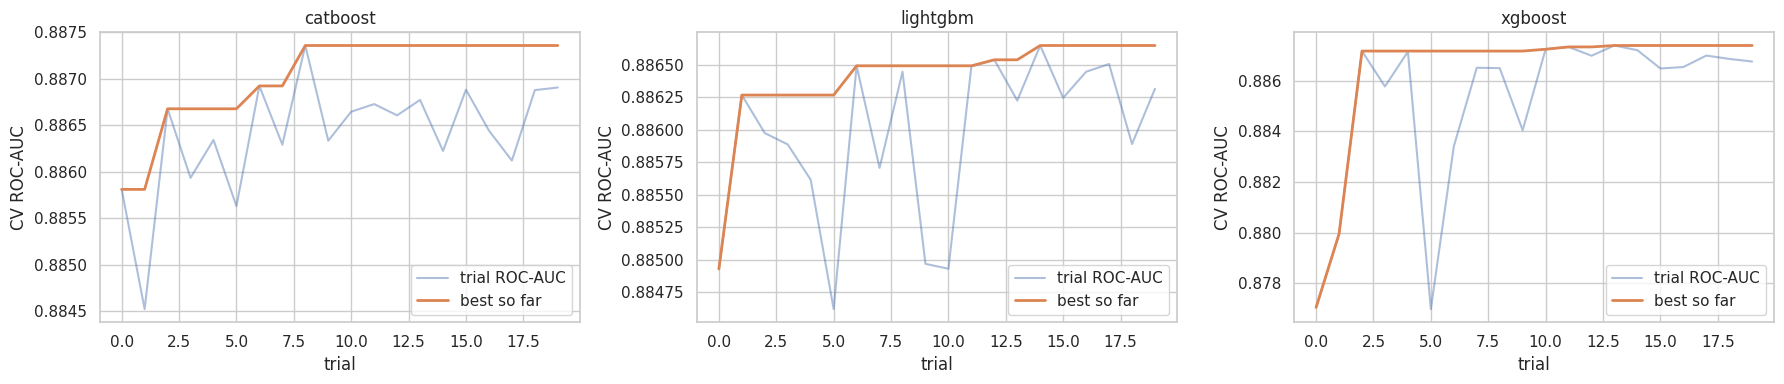

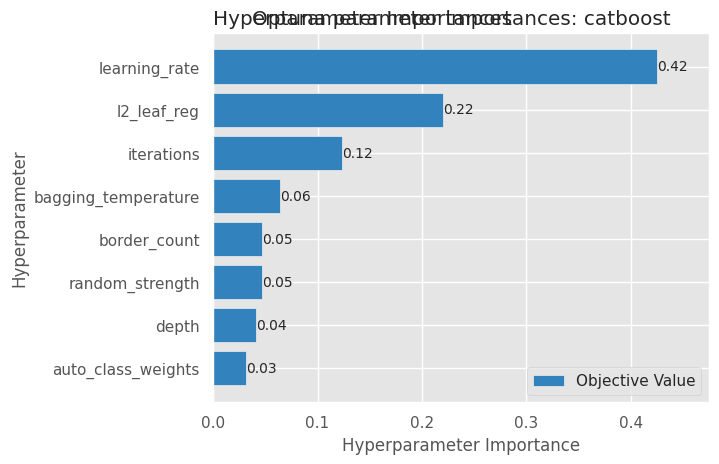

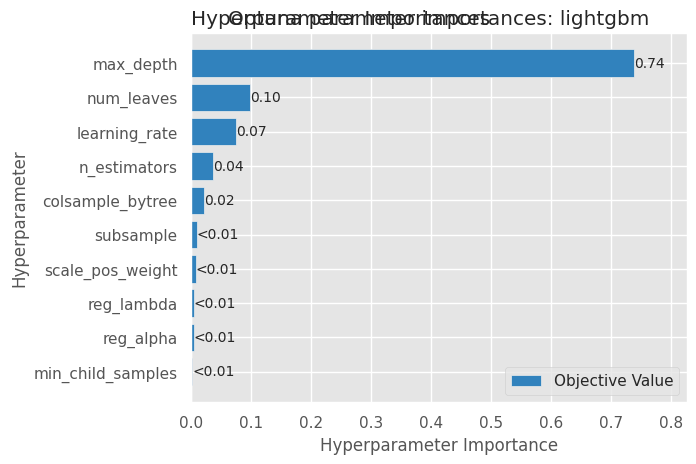

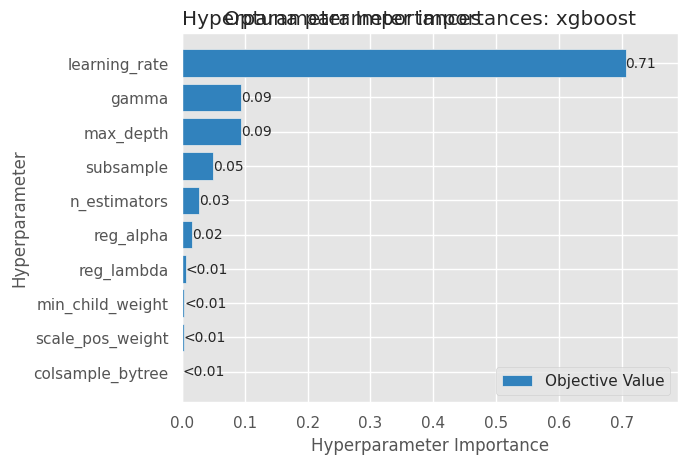

In [ ]:
if RUN_OPTUNA:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for ax, (model_name, study) in zip(axes, studies.items()):
        values = [t.value for t in study.trials if t.value is not None]
        best_so_far = np.maximum.accumulate(values)
        ax.plot(values, alpha=0.45, label="trial ROC-AUC")
        ax.plot(best_so_far, linewidth=2, label="best so far")
        ax.set_title(model_name)
        ax.set_xlabel("trial")
        ax.set_ylabel("CV ROC-AUC")
        ax.legend()
    plt.tight_layout()
    plt.show()

    for model_name, study in studies.items():
        try:
            optuna.visualization.matplotlib.plot_param_importances(study)
            plt.title(f"Optuna parameter importances: {model_name}")
            plt.show()
        except Exception as exc:
            print(f"Could not plot parameter importances for {model_name}: {exc}")


## Оптимизированные модели + SMOTE проверка

SMOTE проверяем только внутри cross-validation pipeline, чтобы синтетические точки не попадали из train-fold в validation-fold. В финальные варианты SMOTE включается только если повышает OOF ROC-AUC.


In [ ]:
tuned_oof = {}
selected_variant = {}
model_reports = []

for model_name in ["catboost", "lightgbm", "xgboost"]:
    print("\n" + "=" * 80)
    print(f"Tuned plain: {model_name}")
    plain_pred, plain_scores = make_oof_predictions(model_name, best_params[model_name], X_fe, y, cv, use_smote=False)
    tuned_oof[(model_name, False)] = plain_pred
    plain_row = summarize_oof(f"tuned_{model_name}", y, plain_pred)
    plain_row.update({"model_name": model_name, "use_smote": False, "fold_mean": plain_scores.mean(), "fold_std": plain_scores.std()})
    model_reports.append(plain_row)

    print("\n" + "=" * 80)
    print(f"Tuned SMOTE: {model_name}")
    smote_pred, smote_scores = make_oof_predictions(model_name, best_params[model_name], X_fe, y, cv, use_smote=True)
    tuned_oof[(model_name, True)] = smote_pred
    smote_row = summarize_oof(f"tuned_{model_name}_smote", y, smote_pred)
    smote_row.update({"model_name": model_name, "use_smote": True, "fold_mean": smote_scores.mean(), "fold_std": smote_scores.std()})
    model_reports.append(smote_row)

    selected_variant[model_name] = bool(smote_row["roc_auc"] > plain_row["roc_auc"])
    print(f"Chosen for {model_name}: use_smote={selected_variant[model_name]}")

model_report = pd.DataFrame(model_reports).sort_values("roc_auc", ascending=False)
model_report


Tuned plain: catboost
catboost | fold 1: ROC-AUC=0.88961 | train_rows=12000 | smote=False
catboost | fold 2: ROC-AUC=0.89856 | train_rows=12000 | smote=False
catboost | fold 3: ROC-AUC=0.88601 | train_rows=12000 | smote=False
catboost | fold 4: ROC-AUC=0.87556 | train_rows=12000 | smote=False
catboost | fold 5: ROC-AUC=0.88706 | train_rows=12000 | smote=False

Tuned SMOTE: catboost
catboost | fold 1: ROC-AUC=0.88479 | train_rows=12000 | smote=True
catboost | fold 2: ROC-AUC=0.89328 | train_rows=12000 | smote=True
catboost | fold 3: ROC-AUC=0.88132 | train_rows=12000 | smote=True
catboost | fold 4: ROC-AUC=0.87241 | train_rows=12000 | smote=True
catboost | fold 5: ROC-AUC=0.88248 | train_rows=12000 | smote=True
Chosen for catboost: use_smote=False

Tuned plain: lightgbm
lightgbm | fold 1: ROC-AUC=0.88996 | train_rows=12000 | smote=False
lightgbm | fold 2: ROC-AUC=0.89739 | train_rows=12000 | smote=False
lightgbm | fold 3: ROC-AUC=0.88385 | train_rows=12000 | smote=False
lightgbm | fold

,name,roc_auc,accuracy@0.5,f1@0.5,model_name,use_smote,fold_mean,fold_std
4,tuned_xgboost,0.887277,0.791333,0.759379,xgboost,False,0.887403,0.007324
0,tuned_catboost,0.886761,0.790267,0.756048,catboost,False,0.887360,0.007372
2,tuned_lightgbm,0.886330,0.787000,0.757936,lightgbm,False,0.886646,0.007172
5,tuned_xgboost_smote,0.886219,0.787200,0.758328,xgboost,True,0.886352,0.007567
3,tuned_lightgbm_smote,0.885321,0.788800,0.756794,lightgbm,True,0.885425,0.006758
1,tuned_catboost_smote,0.882825,0.796200,0.736670,catboost,True,0.882857,0.006694


## Confidence Learning / Cleanlab

Получаем OOF-вероятности лучшей модели и через Cleanlab ищем объекты, где метка выглядит подозрительно относительно предсказаний. Эти объекты не считаем автоматически ошибками: часть из них может быть реально сложными случаями.


In [ ]:
best_variant_row = model_report.iloc[0]
best_model_name = best_variant_row["model_name"]
best_use_smote = bool(best_variant_row["use_smote"])
full_oof_best = tuned_oof[(best_model_name, best_use_smote)]

print("Best base variant:")
print(best_variant_row)

pred_probs_for_cleanlab = np.column_stack([1.0 - full_oof_best, full_oof_best])
ranked_label_issues = find_label_issues(
    labels=y.values,
    pred_probs=pred_probs_for_cleanlab,
    return_indices_ranked_by="self_confidence",
)

self_confidence = pred_probs_for_cleanlab[np.arange(len(y)), y.values]
uncertainty = 1.0 - 2.0 * np.abs(full_oof_best - 0.5)

issues_df = X_fe.iloc[ranked_label_issues].copy()
issues_df["original_label"] = y.iloc[ranked_label_issues].values
issues_df["prob_not_smoking"] = pred_probs_for_cleanlab[ranked_label_issues, 0]
issues_df["prob_smoking"] = pred_probs_for_cleanlab[ranked_label_issues, 1]
issues_df["self_confidence"] = self_confidence[ranked_label_issues]
issues_df["uncertainty"] = uncertainty[ranked_label_issues]

print("Number of Cleanlab ranked issues:", len(ranked_label_issues))
issues_df.head(20)

Best base variant:
name            tuned_xgboost
roc_auc              0.887277
accuracy@0.5         0.791333
f1@0.5               0.759379
model_name            xgboost
use_smote               False
fold_mean            0.887403
fold_std             0.007324
Name: 4, dtype: object
Number of Cleanlab ranked issues: 1736


,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,sex_proxy_score,log1p_triglyceride,log1p_Gtp,log1p_AST,log1p_ALT,original_label,prob_not_smoking,prob_smoking,self_confidence,uncertainty
1476,40.0,160.0,60.0,76.0,1.0,1.0,1.0,1.0,112.0,65.0,...,399.00,4.532599,2.302585,2.995732,2.772589,1,0.992612,0.007388,0.007388,0.014777
13632,40.0,155.0,50.0,74.0,1.2,1.2,1.0,1.0,106.0,64.0,...,403.55,4.127134,2.708050,3.218876,3.044522,1,0.991458,0.008542,0.008542,0.017085
9621,55.0,155.0,65.0,89.0,0.8,0.7,1.0,1.0,122.0,73.0,...,428.25,4.369448,2.708050,3.044522,2.484907,1,0.990767,0.009233,0.009233,0.018467
14814,45.0,155.0,55.0,74.5,1.0,0.9,1.0,1.0,98.0,62.0,...,447.95,3.912023,2.484907,2.890372,2.484907,1,0.990486,0.009514,0.009514,0.019029
13869,40.0,155.0,50.0,73.0,0.7,1.0,1.0,1.0,116.0,74.0,...,438.45,3.871201,2.564949,3.218876,3.044522,1,0.989832,0.010168,0.010168,0.020335
13466,40.0,155.0,60.0,76.0,0.6,0.4,1.0,1.0,105.0,71.0,...,442.35,4.369448,2.772589,3.044522,2.944439,1,0.988610,0.011390,0.011390,0.022780
5424,40.0,160.0,50.0,70.0,1.0,1.2,1.0,1.0,129.0,79.0,...,394.80,4.510860,3.178054,3.496508,2.995732,1,0.987162,0.012838,0.012838,0.025676
12151,40.0,155.0,60.0,79.0,1.0,1.0,1.0,1.0,110.0,63.0,...,407.75,4.356709,2.772589,2.890372,2.708050,1,0.983884,0.016116,0.016116,0.032232
6678,40.0,155.0,45.0,64.0,1.5,1.5,1.0,1.0,114.0,66.0,...,430.85,4.553877,2.397895,2.890372,2.564949,1,0.982163,0.017837,0.017837,0.035674
5282,40.0,165.0,55.0,68.0,1.2,1.0,1.0,1.0,106.0,60.0,...,432.35,4.007333,2.397895,3.135494,2.833213,1,0.981599,0.018401,0.018401,0.036801


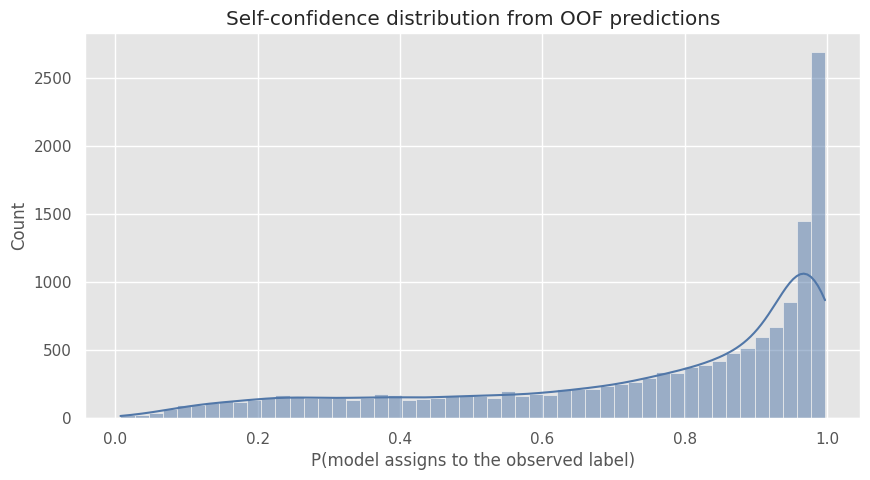

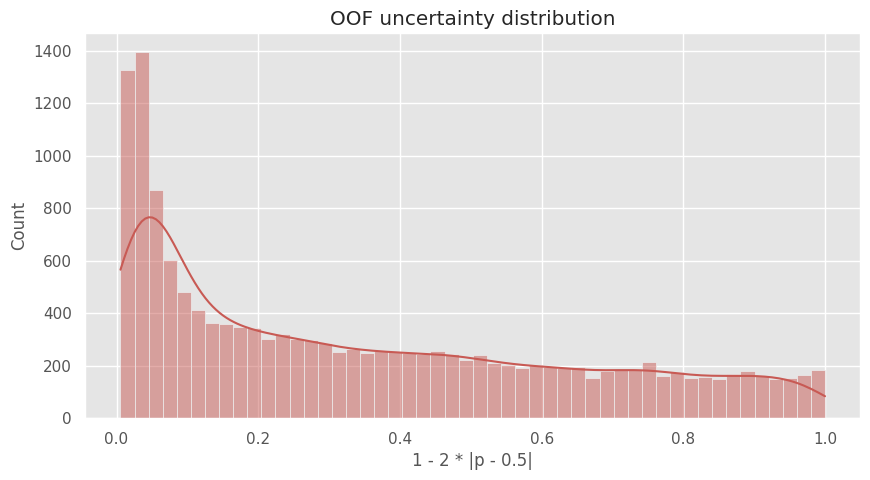

-----------------------------------------------------------
|  Generating a Cleanlab Dataset Health Summary           |
|   for your dataset with 15,000 examples and 2 classes.  |
|  Note, Cleanlab is not a medical doctor... yet.         |
-----------------------------------------------------------

Overall Class Quality and Noise across your dataset (below)
------------------------------------------------------------ 



,Class Name,Class Index,Label Issues,Inverse Label Issues,Label Noise,Inverse Label Noise,Label Quality Score
0,not_smoking,0,1458,278,0.153619,0.03345,0.846381
1,smoking,1,278,1458,0.050463,0.21797,0.949537



Class Overlap. In some cases, you may want to merge classes in the top rows (below)
-----------------------------------------------------------------------------------



,Class Name A,Class Name B,Class Index A,Class Index B,Num Overlapping Examples,Joint Probability
0,not_smoking,smoking,0,1,1736,0.115733



 * Overall, about 8% (1,262 of the 15,000) labels in your dataset have potential issues.
 ** The overall label health score for this dataset is: 0.92.

Generated with <3 from Cleanlab.



In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(self_confidence, bins=50, kde=True, color="#5177a8")
plt.title("Self-confidence distribution from OOF predictions")
plt.xlabel("P(model assigns to the observed label)")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(uncertainty, bins=50, kde=True, color="#c85a54")
plt.title("OOF uncertainty distribution")
plt.xlabel("1 - 2 * |p - 0.5|")
plt.show()

try:
    health_summary(
        labels=y.values,
        pred_probs=pred_probs_for_cleanlab,
        class_names=["not_smoking", "smoking"],
        verbose=True,
    )
except Exception as exc:
    print(f"Cleanlab health_summary failed, continuing: {exc}")

In [ ]:
cleaning_fractions = [0.0, 0.005, 0.01, 0.02, 0.03]
cleaning_reports = []
cleaning_masks = {}

for frac in cleaning_fractions:
    n_remove = int(round(len(y) * frac))
    keep_mask = np.ones(len(y), dtype=bool)
    if n_remove > 0:
        remove_idx = ranked_label_issues[:n_remove]
        keep_mask[remove_idx] = False

    cleaning_masks[frac] = keep_mask
    print("\n" + "=" * 80)
    print(f"Cleaning strategy: remove top {frac:.3%} ({n_remove} rows)")

    pred, scores = make_oof_predictions(
        best_model_name,
        best_params[best_model_name],
        X_fe,
        y,
        cv,
        use_smote=best_use_smote,
        train_mask=keep_mask,
    )
    row = summarize_oof(f"clean_remove_{frac:.3%}", y, pred)
    row.update({"remove_fraction": frac, "removed_rows": n_remove, "fold_mean": scores.mean(), "fold_std": scores.std()})
    cleaning_reports.append(row)

cleaning_report = pd.DataFrame(cleaning_reports).sort_values("roc_auc", ascending=False)
best_cleaning = cleaning_report.iloc[0]
best_clean_fraction = float(best_cleaning["remove_fraction"])
best_clean_mask = cleaning_masks[best_clean_fraction]

print("Best cleaning strategy:")
print(best_cleaning)
cleaning_report


Cleaning strategy: remove top 0.000% (0 rows)
xgboost | fold 1: ROC-AUC=0.89143 | train_rows=12000 | smote=False
xgboost | fold 2: ROC-AUC=0.89807 | train_rows=12000 | smote=False
xgboost | fold 3: ROC-AUC=0.88562 | train_rows=12000 | smote=False
xgboost | fold 4: ROC-AUC=0.87587 | train_rows=12000 | smote=False
xgboost | fold 5: ROC-AUC=0.88601 | train_rows=12000 | smote=False

Cleaning strategy: remove top 0.500% (75 rows)
xgboost | fold 1: ROC-AUC=0.89174 | train_rows=11942 | smote=False
xgboost | fold 2: ROC-AUC=0.89875 | train_rows=11936 | smote=False
xgboost | fold 3: ROC-AUC=0.88489 | train_rows=11939 | smote=False
xgboost | fold 4: ROC-AUC=0.87596 | train_rows=11946 | smote=False
xgboost | fold 5: ROC-AUC=0.88595 | train_rows=11937 | smote=False

Cleaning strategy: remove top 1.000% (150 rows)
xgboost | fold 1: ROC-AUC=0.89178 | train_rows=11883 | smote=False
xgboost | fold 2: ROC-AUC=0.89942 | train_rows=11872 | smote=False
xgboost | fold 3: ROC-AUC=0.88609 | train_rows=11879

,name,roc_auc,accuracy@0.5,f1@0.5,remove_fraction,removed_rows,fold_mean,fold_std
4,clean_remove_3.000%,0.888547,0.793333,0.759354,0.030,450,0.888589,0.007658
3,clean_remove_2.000%,0.888192,0.792200,0.758765,0.020,300,0.888241,0.007783
2,clean_remove_1.000%,0.887615,0.792200,0.759769,0.010,150,0.887686,0.007745
1,clean_remove_0.500%,0.887381,0.791067,0.759219,0.005,75,0.887456,0.007575
0,clean_remove_0.000%,0.887277,0.791333,0.759379,0.000,0,0.887403,0.007324


## Создание отдельной модли для "сложных" данных

Используем Cleanlab issues не только как кандидатов на удаление, но и как источник сложных объектов. Hard/noisy expert обучается на подозрительных объектах плюс самых uncertain объектах, чтобы выборка была достаточно большой и не состояла только из потенциально ошибочной разметки.


Rows for clean expert: 14550
Rows for hard/noisy expert: 1650
Hard subset class balance:
smoking
0    0.650303
1    0.349697
Name: share, dtype: float64


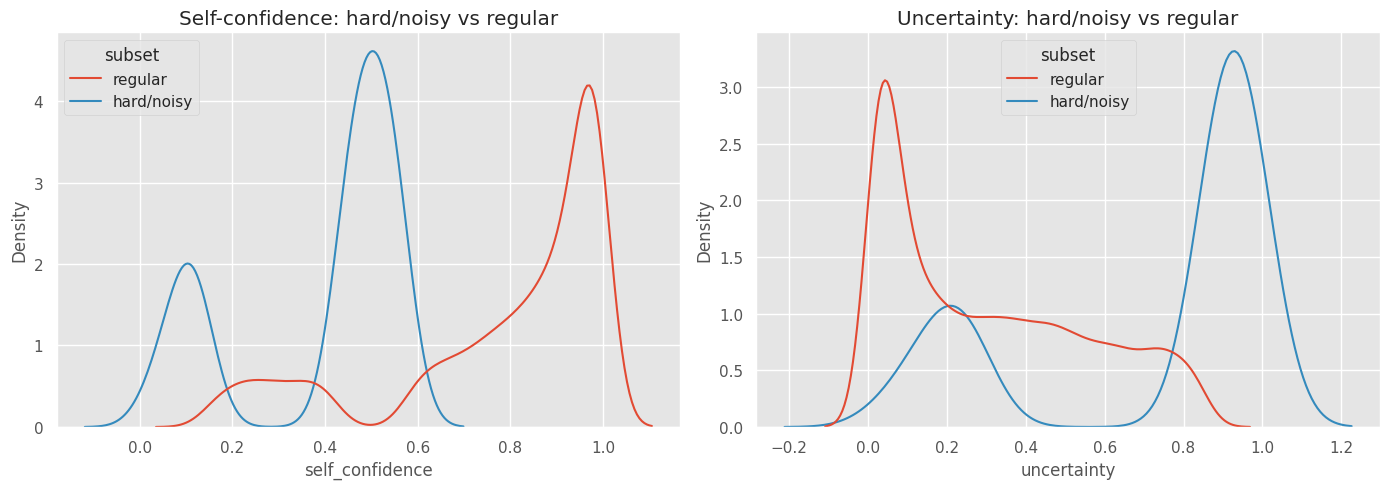

In [ ]:
best_removed_count = int(best_cleaning["removed_rows"])
issue_count_for_expert = max(best_removed_count, int(0.02 * len(y)))
min_hard_size = max(1200, int(0.08 * len(y)))

hard_mask = np.zeros(len(y), dtype=bool)
hard_mask[ranked_label_issues[:issue_count_for_expert]] = True

if hard_mask.sum() < min_hard_size:
    uncertain_order = np.argsort(-uncertainty)
    hard_mask[uncertain_order[:min_hard_size]] = True

clean_expert_mask = best_clean_mask.copy()

print("Rows for clean expert:", int(clean_expert_mask.sum()))
print("Rows for hard/noisy expert:", int(hard_mask.sum()))
print("Hard subset class balance:")
print(y[hard_mask].value_counts(normalize=True).rename("share"))

plot_df = pd.DataFrame({
    "subset": np.where(hard_mask, "hard/noisy", "regular"),
    "self_confidence": self_confidence,
    "uncertainty": uncertainty,
    TARGET: y.values,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(data=plot_df, x="self_confidence", hue="subset", common_norm=False, ax=axes[0])
axes[0].set_title("Self-confidence: hard/noisy vs regular")
sns.kdeplot(data=plot_df, x="uncertainty", hue="subset", common_norm=False, ax=axes[1])
axes[1].set_title("Uncertainty: hard/noisy vs regular")
plt.tight_layout()
plt.show()

In [ ]:

selected_oof_matrix = []
selected_names = []
for model_name in ["catboost", "lightgbm", "xgboost"]:
    use_smote = selected_variant[model_name]
    selected_oof_matrix.append(tuned_oof[(model_name, use_smote)])
    selected_names.append(f"{model_name}_smote={use_smote}")
selected_oof_matrix = np.column_stack(selected_oof_matrix)


def normalize_ranks(values):
    # Для ROC-AUC важен порядок объектов. Ранги убирают различия в калибровке вероятностей моделей.
    return pd.Series(values).rank(method="average").to_numpy() / len(values)


def rank_average(pred_matrix):
    # Усредняем не вероятности, а ранги предсказаний. Часто это устойчивее на leaderboard.
    ranked = np.column_stack([normalize_ranks(pred_matrix[:, i]) for i in range(pred_matrix.shape[1])])
    return ranked.mean(axis=1)


def optimize_blend_weights(pred_matrix, y_true, n_trials=1500, study_name="blend"):
    n_models = pred_matrix.shape[1]

    def objective(trial):
        raw = np.array([trial.suggest_float(f"w{i}", 0.0, 1.0) for i in range(n_models)])
        if raw.sum() == 0:
            raw = np.ones(n_models)
        weights = raw / raw.sum()
        blended = pred_matrix @ weights
        return roc_auc_score(y_true, blended)

    study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RANDOM_STATE), study_name=study_name)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    raw_weights = np.array([study.best_params[f"w{i}"] for i in range(n_models)])
    weights = raw_weights / raw_weights.sum()
    pred = pred_matrix @ weights
    return weights, pred, study


full_weights, pred_full_model, full_blend_study = optimize_blend_weights(
    selected_oof_matrix,
    y,
    n_trials=1200,
    study_name="full_tree_blend",
)

# pred_tree_rank_average — альтернативный ансамбль для ROC-AUC: порядок объектов важнее точной вероятности.
pred_tree_rank_average = rank_average(selected_oof_matrix)

print("Selected full ensemble members:", selected_names)
print("Full ensemble weights:", dict(zip(selected_names, full_weights.round(4))))
print("Full ensemble ROC-AUC:", roc_auc_score(y, pred_full_model))
print("Tree rank-average ROC-AUC:", roc_auc_score(y, pred_tree_rank_average))


[I 2026-06-02 19:25:25,190] A new study created in memory with name: full_tree_blend
[I 2026-06-02 19:25:25,198] Trial 0 finished with value: 0.8875995083877172 and parameters: {'w0': 0.3745401188473625, 'w1': 0.9507143064099162, 'w2': 0.7319939418114051}. Best is trial 0 with value: 0.8875995083877172.
[I 2026-06-02 19:25:25,205] Trial 1 finished with value: 0.8876287514426207 and parameters: {'w0': 0.5986584841970366, 'w1': 0.15601864044243652, 'w2': 0.15599452033620265}. Best is trial 1 with value: 0.8876287514426207.
[I 2026-06-02 19:25:25,211] Trial 2 finished with value: 0.8872316081888127 and parameters: {'w0': 0.05808361216819946, 'w1': 0.8661761457749352, 'w2': 0.6011150117432088}. Best is trial 1 with value: 0.8876287514426207.
[I 2026-06-02 19:25:25,217] Trial 3 finished with value: 0.8879345507917724 and parameters: {'w0': 0.7080725777960455, 'w1': 0.020584494295802447, 'w2': 0.9699098521619943}. Best is trial 3 with value: 0.8879345507917724.
[I 2026-06-02 19:25:25,222] Tr

Selected full ensemble members: ['catboost_smote=False', 'lightgbm_smote=False', 'xgboost_smote=False']
Full ensemble weights: {'catboost_smote=False': np.float64(0.4164), 'lightgbm_smote=False': np.float64(0.0386), 'xgboost_smote=False': np.float64(0.545)}
Full ensemble ROC-AUC: 0.8879403458510502
Tree rank-average ROC-AUC: 0.8878522437369801


In [ ]:
noisy_expert_model_name = "catboost"

conservative_noisy_params = {
    "iterations": 900,
    "learning_rate": 0.025,
    "depth": 4,
    "l2_leaf_reg": 15.0,
    "random_strength": 2.0,
    "bagging_temperature": 1.0,
    "auto_class_weights": "SqrtBalanced",
}

print("\nClean expert OOF")
pred_clean_expert, clean_expert_scores = make_oof_predictions(
    best_model_name,
    best_params[best_model_name],
    X_fe,
    y,
    cv,
    use_smote=best_use_smote,
    train_mask=clean_expert_mask,
)

print("\nHard/noisy expert OOF")
pred_noisy_expert, noisy_expert_scores = make_oof_predictions(
    noisy_expert_model_name,
    conservative_noisy_params,
    X_fe,
    y,
    cv,
    use_smote=False,
    train_mask=hard_mask,
    min_subset_size=300,
)

expert_matrix = np.column_stack([pred_full_model, pred_clean_expert, pred_noisy_expert])
expert_names = ["full_tree_blend", "clean_expert", "hard_noisy_expert"]
expert_weights, pred_expert_blend, expert_blend_study = optimize_blend_weights(expert_matrix, y, n_trials=1200, study_name="expert_blend")

print("Expert blend weights:", dict(zip(expert_names, expert_weights.round(4))))
print("Expert blend ROC-AUC:", roc_auc_score(y, pred_expert_blend))


Clean expert OOF
xgboost | fold 1: ROC-AUC=0.89235 | train_rows=11641 | smote=False
xgboost | fold 2: ROC-AUC=0.90008 | train_rows=11627 | smote=False
xgboost | fold 3: ROC-AUC=0.88740 | train_rows=11639 | smote=False
xgboost | fold 4: ROC-AUC=0.87672 | train_rows=11647 | smote=False
xgboost | fold 5: ROC-AUC=0.88638 | train_rows=11646 | smote=False

Hard/noisy expert OOF
catboost | fold 1: ROC-AUC=0.19655 | train_rows=1342 | smote=False
catboost | fold 2: ROC-AUC=0.15959 | train_rows=1331 | smote=False
catboost | fold 3: ROC-AUC=0.18647 | train_rows=1321 | smote=False
catboost | fold 4: ROC-AUC=0.19891 | train_rows=1306 | smote=False


[I 2026-06-02 19:26:25,950] A new study created in memory with name: expert_blend
[I 2026-06-02 19:26:25,957] Trial 0 finished with value: 0.8888174844932916 and parameters: {'w0': 0.3745401188473625, 'w1': 0.9507143064099162, 'w2': 0.7319939418114051}. Best is trial 0 with value: 0.8888174844932916.
[I 2026-06-02 19:26:25,963] Trial 1 finished with value: 0.8884152729533166 and parameters: {'w0': 0.5986584841970366, 'w1': 0.15601864044243652, 'w2': 0.15599452033620265}. Best is trial 0 with value: 0.8888174844932916.
[I 2026-06-02 19:26:25,969] Trial 2 finished with value: 0.888435144460213 and parameters: {'w0': 0.05808361216819946, 'w1': 0.8661761457749352, 'w2': 0.6011150117432088}. Best is trial 0 with value: 0.8888174844932916.
[I 2026-06-02 19:26:25,974] Trial 3 finished with value: 0.887823258877787 and parameters: {'w0': 0.7080725777960455, 'w1': 0.020584494295802447, 'w2': 0.9699098521619943}. Best is trial 0 with value: 0.8888174844932916.
[I 2026-06-02 19:26:25,980] Trial 4

catboost | fold 5: ROC-AUC=0.20216 | train_rows=1300 | smote=False


[I 2026-06-02 19:26:26,151] Trial 22 finished with value: 0.8888698121572656 and parameters: {'w0': 0.3239241466011445, 'w1': 0.8704727514719295, 'w2': 0.13881283755258755}. Best is trial 22 with value: 0.8888698121572656.
[I 2026-06-02 19:26:26,161] Trial 23 finished with value: 0.8888610908799366 and parameters: {'w0': 0.2954542624858081, 'w1': 0.9132451055679672, 'w2': 0.23446895684728603}. Best is trial 22 with value: 0.8888698121572656.
[I 2026-06-02 19:26:26,171] Trial 24 finished with value: 0.8887798452963981 and parameters: {'w0': 0.1261317316359921, 'w1': 0.8709340451256585, 'w2': 0.14228423155750847}. Best is trial 22 with value: 0.8888698121572656.
[I 2026-06-02 19:26:26,182] Trial 25 finished with value: 0.8888665608038753 and parameters: {'w0': 0.35835666028704966, 'w1': 0.6617702146172972, 'w2': 0.003784865609935295}. Best is trial 22 with value: 0.8888698121572656.
[I 2026-06-02 19:26:26,193] Trial 26 finished with value: 0.888867708340366 and parameters: {'w0': 0.21039

Expert blend weights: {'full_tree_blend': np.float64(0.2679), 'clean_expert': np.float64(0.6216), 'hard_noisy_expert': np.float64(0.1105)}
Expert blend ROC-AUC: 0.8888771563908057


In [ ]:

def uncertainty_gated_blend(full_pred, clean_pred, noisy_pred, uncertainty_score, noisy_weight_grid=None):
    """Честный gate только по uncertainty, доступной и на OOF, и на test.

    Старый gate использовал self_confidence, а она зависит от настоящей метки y.
    Это завышало OOF и не воспроизводилось на test.
    """
    if noisy_weight_grid is None:
        noisy_weight_grid = np.linspace(0.0, 0.30, 7)

    rows = []
    best = None
    for q in np.linspace(0.60, 0.95, 16):
        # Берём только самые неопределённые объекты: чем выше uncertainty, тем ближе p к 0.5.
        threshold = np.quantile(uncertainty_score, q)
        gate = (uncertainty_score >= threshold).astype(float)
        for noisy_weight in noisy_weight_grid:
            # На простых объектах используем full + clean experts, на неопределённых добавляем noisy expert.
            base_weight = 1.0 - noisy_weight * gate
            pred = base_weight * (0.70 * full_pred + 0.30 * clean_pred) + (noisy_weight * gate) * noisy_pred
            auc = roc_auc_score(y, pred)
            row = {"gate_quantile": q, "threshold": threshold, "noisy_weight": noisy_weight, "roc_auc": auc, "pred": pred}
            rows.append({k: v for k, v in row.items() if k != "pred"})
            if best is None or auc > best["roc_auc"]:
                best = row
    return best, pd.DataFrame(rows)


best_uncertainty_gate, uncertainty_gated_search_report = uncertainty_gated_blend(
    pred_full_model,
    pred_clean_expert,
    pred_noisy_expert,
    uncertainty,
)

# pred_uncertainty_gated_blend — ансамбль, который усиливает noisy expert только на сложных объектах.
pred_uncertainty_gated_blend = best_uncertainty_gate["pred"]

print("Best honest uncertainty-gated blend:")
print({k: v for k, v in best_uncertainty_gate.items() if k != "pred"})
uncertainty_gated_search_report.sort_values("roc_auc", ascending=False).head(10)


Best honest uncertainty-gated blend:
{'gate_quantile': np.float64(0.95), 'threshold': np.float64(0.9083415687084198), 'noisy_weight': np.float64(0.3), 'roc_auc': np.float64(0.8886010399855456)}


,gate_quantile,threshold,noisy_weight,roc_auc
111,0.950000,0.908342,0.30,0.888601
110,0.950000,0.908342,0.25,0.888601
109,0.950000,0.908342,0.20,0.888597
108,0.950000,0.908342,0.15,0.888596
107,0.950000,0.908342,0.10,0.888593
106,0.950000,0.908342,0.05,0.888589
81,0.856667,0.743092,0.20,0.888589
88,0.880000,0.780880,0.20,0.888588
90,0.880000,0.780880,0.30,0.888588
82,0.856667,0.743092,0.25,0.888588



## Сравниваем конфиги обучения

Важно: прежний `expert_gated_blend` был исключён из финального выбора, потому что его OOF-gate использовал `self_confidence`, зависящий от настоящей метки `y`. На test такой gate недоступен, поэтому это давало завышенный OOF и хуже переносилось на leaderboard.

Ниже остаются только честные варианты: одиночные модели, Cleanlab-clean expert, weighted blend, rank-average и uncertainty-gated blend без использования true labels в gate.


In [ ]:

comparison_rows = []

for _, row in baseline_report.iterrows():
    comparison_rows.append({"variant": row["name"], "roc_auc": row["roc_auc"]})
for _, row in model_report.iterrows():
    comparison_rows.append({"variant": row["name"], "roc_auc": row["roc_auc"]})
for _, row in cleaning_report.iterrows():
    comparison_rows.append({"variant": row["name"], "roc_auc": row["roc_auc"]})

extra_variants = {
    "full_tree_blend": pred_full_model,
    "tree_rank_average": pred_tree_rank_average,
    "clean_expert": pred_clean_expert,
    "hard_noisy_expert": pred_noisy_expert,
    "expert_weighted_blend": pred_expert_blend,
    "uncertainty_gated_blend": pred_uncertainty_gated_blend,
}
for name, pred in extra_variants.items():
    comparison_rows.append({"variant": name, "roc_auc": roc_auc_score(y, pred)})

comparison = pd.DataFrame(comparison_rows).drop_duplicates("variant").sort_values("roc_auc", ascending=False)
comparison.head(20)


,variant,roc_auc
18,expert_weighted_blend,0.888877
19,uncertainty_gated_blend,0.888601
16,clean_expert,0.888547
9,clean_remove_3.000%,0.888547
10,clean_remove_2.000%,0.888192
14,full_tree_blend,0.887940
15,tree_rank_average,0.887852
11,clean_remove_1.000%,0.887615
12,clean_remove_0.500%,0.887381
13,clean_remove_0.000%,0.887277


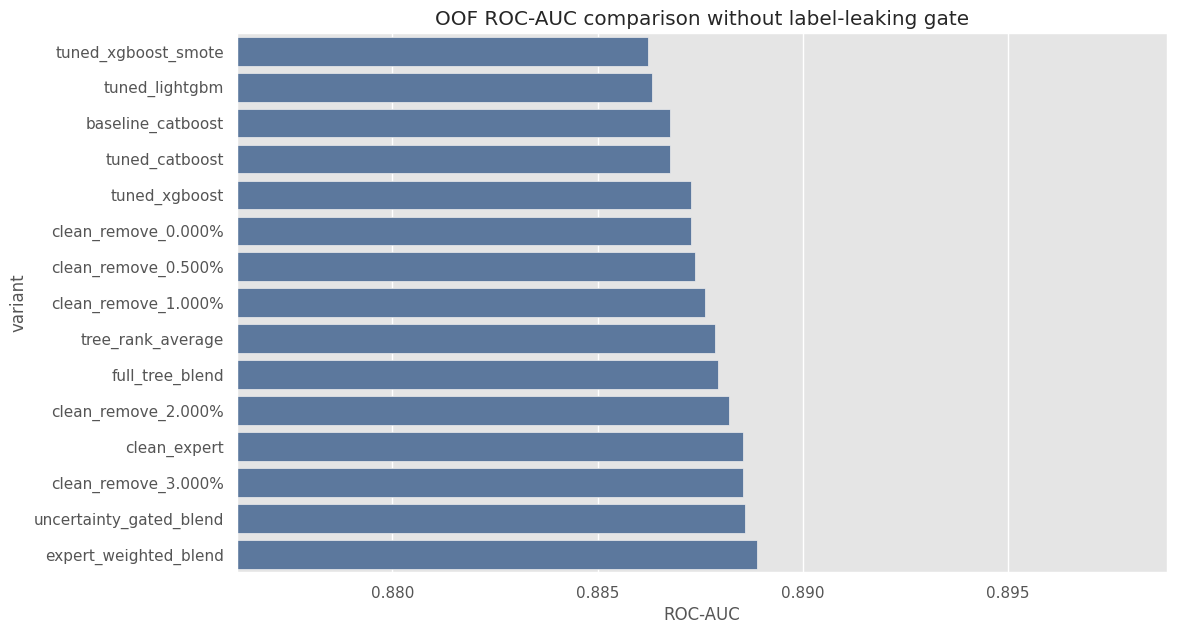

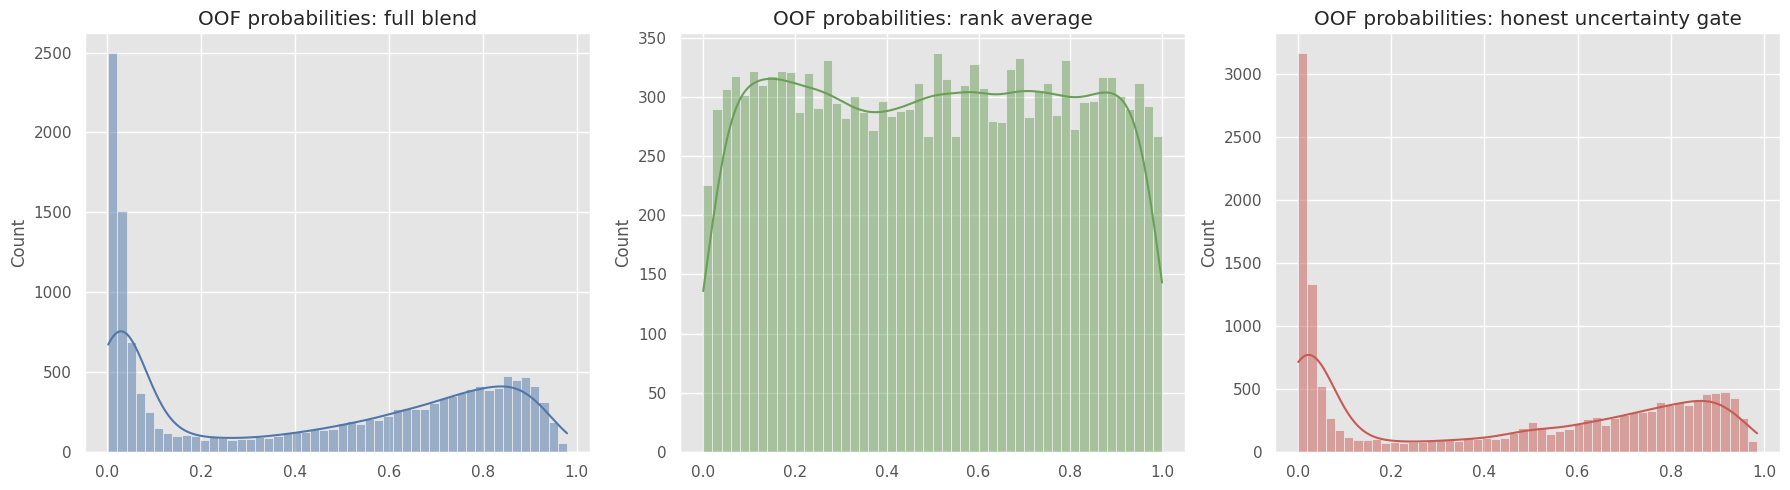

Confusion matrix at threshold 0.5 for the best OOF variant:
expert_weighted_blend
[[6986 2505]
 [ 605 4904]]


In [ ]:

plt.figure(figsize=(12, 7))
plot_data = comparison.head(15).sort_values("roc_auc")
sns.barplot(data=plot_data, x="roc_auc", y="variant", color="#5177a8")
plt.title("OOF ROC-AUC comparison without label-leaking gate")
plt.xlabel("ROC-AUC")
plt.ylabel("variant")
plt.xlim(max(0.5, plot_data["roc_auc"].min() - 0.01), min(1.0, plot_data["roc_auc"].max() + 0.01))
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(pred_full_model, bins=50, kde=True, ax=axes[0], color="#5177a8")
axes[0].set_title("OOF probabilities: full blend")
sns.histplot(pred_tree_rank_average, bins=50, kde=True, ax=axes[1], color="#6a9f58")
axes[1].set_title("OOF probabilities: rank average")
sns.histplot(pred_uncertainty_gated_blend, bins=50, kde=True, ax=axes[2], color="#c85a54")
axes[2].set_title("OOF probabilities: honest uncertainty gate")
plt.tight_layout()
plt.show()

print("Confusion matrix at threshold 0.5 for the best OOF variant:")
best_variant_name = comparison.iloc[0]["variant"]
best_oof_lookup = {
    **{f"baseline_{name}": pred for name, pred in baseline_oof.items()},
    **{f"tuned_{name}": tuned_oof[(name, False)] for name in ["catboost", "lightgbm", "xgboost"]},
    **{f"tuned_{name}_smote": tuned_oof[(name, True)] for name in ["catboost", "lightgbm", "xgboost"]},
    **extra_variants,
}
best_oof_pred = best_oof_lookup.get(best_variant_name, pred_full_model)
print(best_variant_name)
print(confusion_matrix(y, (best_oof_pred >= 0.5).astype(int)))


## Обучение финальной модели и предсказание

Финальная конфигурация выбирается по OOF ROC-AUC. Для test используем те же веса и gating-логику, что были выбраны на OOF.


In [ ]:

final_variant_name = comparison.iloc[0]["variant"]
print("Final variant selected by OOF ROC-AUC:", final_variant_name)
print("OOF ROC-AUC:", comparison.iloc[0]["roc_auc"])

test_pred_by_model = {}
fitted_models = {}
for model_name in ["catboost", "lightgbm", "xgboost"]:
    use_smote = selected_variant[model_name]
    fitted_model, test_pred = fit_full_and_predict(
        model_name,
        best_params[model_name],
        X_fe,
        y,
        X_test_fe,
        use_smote=use_smote,
    )
    fitted_models[(model_name, use_smote)] = fitted_model
    test_pred_by_model[model_name] = test_pred
    print(f"Test prediction ready: {model_name}, use_smote={use_smote}")

selected_test_matrix = np.column_stack([test_pred_by_model[name] for name in ["catboost", "lightgbm", "xgboost"]])
test_pred_full_model = selected_test_matrix @ full_weights
test_pred_tree_rank_average = rank_average(selected_test_matrix)

X_clean_final = X_fe.iloc[np.where(clean_expert_mask)[0]]
y_clean_final = y.iloc[np.where(clean_expert_mask)[0]]
clean_model, test_pred_clean_expert = fit_full_and_predict(
    best_model_name,
    best_params[best_model_name],
    X_clean_final,
    y_clean_final,
    X_test_fe,
    use_smote=best_use_smote,
)

X_hard_final = X_fe.iloc[np.where(hard_mask)[0]]
y_hard_final = y.iloc[np.where(hard_mask)[0]]
noisy_model, test_pred_noisy_expert = fit_full_and_predict(
    noisy_expert_model_name,
    conservative_noisy_params,
    X_hard_final,
    y_hard_final,
    X_test_fe,
    use_smote=False,
)

test_pred_expert_blend = np.column_stack([
    test_pred_full_model,
    test_pred_clean_expert,
    test_pred_noisy_expert,
]) @ expert_weights

uncertainty_test = 1.0 - 2.0 * np.abs(test_pred_full_model - 0.5)
test_gate_threshold = np.quantile(uncertainty, best_uncertainty_gate["gate_quantile"])
test_gate = (uncertainty_test >= test_gate_threshold).astype(float)
test_pred_uncertainty_gated_blend = (
    (1.0 - best_uncertainty_gate["noisy_weight"] * test_gate) * (0.70 * test_pred_full_model + 0.30 * test_pred_clean_expert)
    + (best_uncertainty_gate["noisy_weight"] * test_gate) * test_pred_noisy_expert
)

if final_variant_name == "full_tree_blend":
    final_test_pred = test_pred_full_model
elif final_variant_name == "tree_rank_average":
    final_test_pred = test_pred_tree_rank_average
elif final_variant_name == "clean_expert":
    final_test_pred = test_pred_clean_expert
elif final_variant_name == "hard_noisy_expert":
    final_test_pred = test_pred_noisy_expert
elif final_variant_name == "expert_weighted_blend":
    final_test_pred = test_pred_expert_blend
elif final_variant_name == "uncertainty_gated_blend":
    final_test_pred = test_pred_uncertainty_gated_blend
elif final_variant_name.startswith("tuned_"):
    single_model_name = final_variant_name.replace("tuned_", "").split("_smote")[0]
    final_test_pred = test_pred_by_model[single_model_name]
else:
    final_test_pred = test_pred_full_model

final_test_pred = np.clip(final_test_pred, 0.0, 1.0)

submission = pd.DataFrame({
    ID_COL: test_ids.values,
    TARGET: final_test_pred,
})

assert submission.shape[0] == len(test_ids) == len(X_test_fe)
assert list(submission.columns) == [ID_COL, TARGET]
assert submission[ID_COL].is_unique
assert submission[TARGET].between(0, 1).all()
assert np.isfinite(submission[TARGET]).all()
assert not submission[TARGET].isna().any()

submission_path = DATA_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)
print("Saved:", submission_path)
submission.head()


Final variant selected by OOF ROC-AUC: expert_weighted_blend
OOF ROC-AUC: 0.8888771563908057
Test prediction ready: catboost, use_smote=False
Test prediction ready: lightgbm, use_smote=False
Test prediction ready: xgboost, use_smote=False
Saved: submission.csv


,id,smoking
0,15000,0.841637
1,15001,0.562147
2,15002,0.493661
3,15003,0.598422
4,15004,0.809643


## Финальная проверка

Эти графики помогают проверить, что финальные вероятности выглядят адекватно: нет NaN, нет выхода за `[0, 1]`, нет почти константного предсказания.


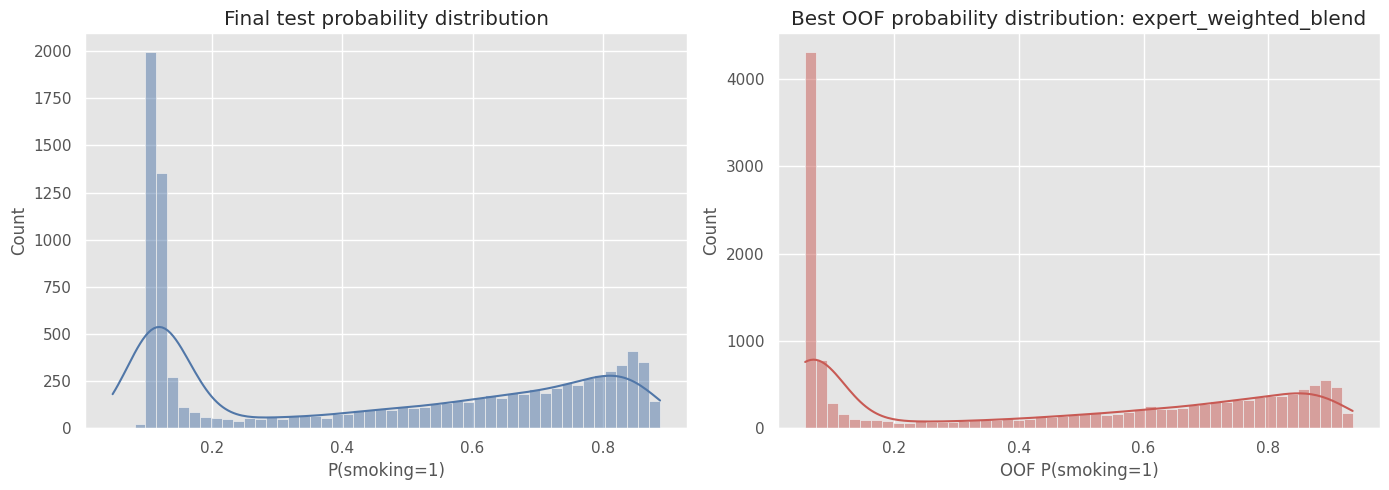

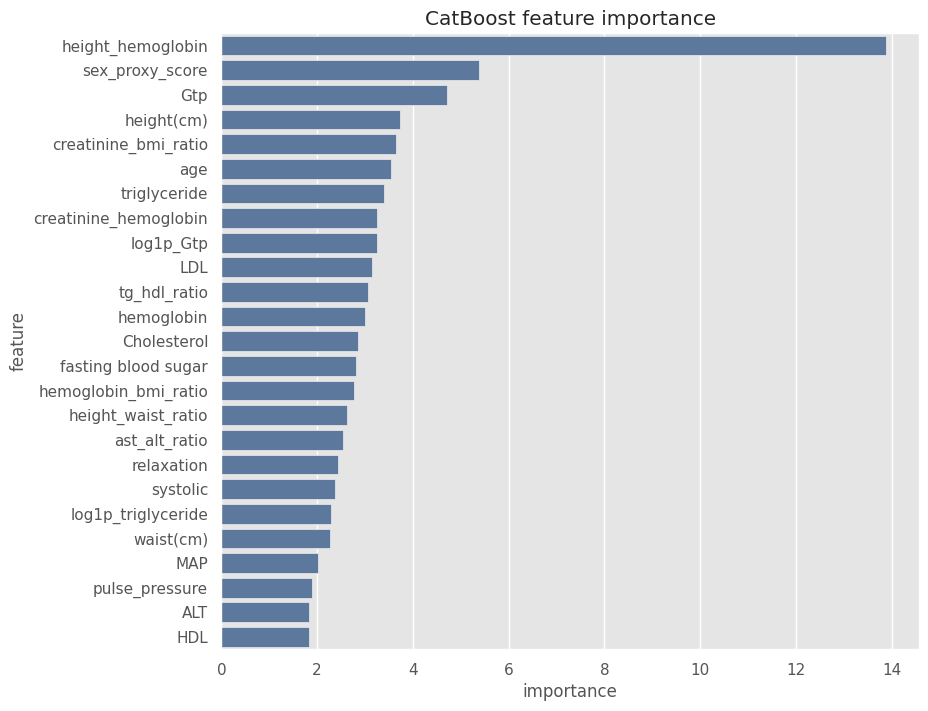

,importance
height_hemoglobin,13.871502
sex_proxy_score,5.377966
Gtp,4.704591
height(cm),3.740325
creatinine_bmi_ratio,3.644967
age,3.534787
triglyceride,3.404202
creatinine_hemoglobin,3.255887
log1p_Gtp,3.246505
LDL,3.143353


Final variant: expert_weighted_blend
Best OOF ROC-AUC: 0.8888771563908057
Submission probability summary:
count    10000.000000
mean         0.445532
std          0.295338
min          0.047481
25%          0.117268
50%          0.471038
75%          0.742094
max          0.887705
Name: smoking, dtype: float64


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(final_test_pred, bins=50, kde=True, ax=axes[0], color="#5177a8")
axes[0].set_title("Final test probability distribution")
axes[0].set_xlabel("P(smoking=1)")

sns.histplot(best_oof_pred, bins=50, kde=True, ax=axes[1], color="#c85a54")
axes[1].set_title(f"Best OOF probability distribution: {best_variant_name}")
axes[1].set_xlabel("OOF P(smoking=1)")
plt.tight_layout()
plt.show()

try:
    if ("catboost", selected_variant["catboost"]) in fitted_models:
        cat_model = fitted_models[("catboost", selected_variant["catboost"])]
        cat_estimator = cat_model.named_steps["model"] if isinstance(cat_model, ImbPipeline) else cat_model
        importances = pd.Series(cat_estimator.get_feature_importance(), index=X_fe.columns).sort_values(ascending=False)
        plt.figure(figsize=(9, 8))
        sns.barplot(x=importances.head(25).values, y=importances.head(25).index, color="#5177a8")
        plt.title("CatBoost feature importance")
        plt.xlabel("importance")
        plt.ylabel("feature")
        plt.show()
        display(importances.head(30).to_frame("importance"))
except Exception as exc:
    print(f"Could not plot CatBoost feature importance: {exc}")

print("Final variant:", final_variant_name)
print("Best OOF ROC-AUC:", comparison.iloc[0]["roc_auc"])
print("Submission probability summary:")
print(submission[TARGET].describe())
